# Monte Carlo flight viewer

Load the pickle generated by `montecarlorunner.py`, reduce each complete RocketPy state history to flight-level metrics with NumPy, and analyze the results with pandas. The plots show distributions of peak altitude, ignition attitude angle from vertical, and maximum 3D velocity.

> Only open pickle files you trust. Python pickle files can execute code while loading.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Select the Monte Carlo file

Change `PKL_PATH` if the runner output has a different name. `HISTOGRAM_BINS` accepts an integer or any NumPy histogram strategy such as `"auto"`, `"fd"`, or `"sturges"`.

In [2]:
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "montecarlorunner.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

PKL_PATH = PROJECT_DIR / "monte_carlo_flights.pkl"
if not PKL_PATH.is_file():
    PKL_PATH = PROJECT_DIR / "flight_data.pkl"

HISTOGRAM_BINS = "auto"
print(f"Loading: {PKL_PATH}")

Loading: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_flights.pkl


## Load and validate the results

In [3]:
from montecarlorunner import load_monte_carlo_output

monte_carlo = load_monte_carlo_output(PKL_PATH)

if not isinstance(monte_carlo, dict):
    raise TypeError("Expected the dictionary format written by montecarlorunner.py")
if monte_carlo.get("format") != "projectblaze.rocketpy.monte_carlo":
    raise ValueError(f"Unsupported Monte Carlo format: {monte_carlo.get('format')!r}")

flights = monte_carlo.get("flights", [])
state_columns = tuple(monte_carlo.get("state_columns", ()))
required_columns = {"time", "z", "vx", "vy", "vz", "e0", "e1", "e2", "e3"}
missing_columns = required_columns.difference(state_columns)
if not flights:
    raise ValueError("The pickle contains no flight records")
if missing_columns:
    raise ValueError(f"Flight state data is missing columns: {sorted(missing_columns)}")

print(f"Loaded {len(flights):,} flight records")
print(f"Created: {monte_carlo.get('created_at_utc', 'unknown')}")

Loaded 50 flight records
Created: 2026-08-24T07:00:03.892375+00:00


## Vectorized flight processing

Altitude is reported as peak height above the launch-site elevation. Ignition values use the state nearest the recorded sustainer ignition time. Maximum velocity is the largest magnitude of `(vx, vy, vz)`. Because the streamed output does not retain the atmospheric and wind profiles, Mach number and dynamic pressure are offline estimates based on the 1976 standard atmosphere and ground-relative velocity.

In [4]:
column = {name: index for index, name in enumerate(state_columns)}
launch_elevation_m = float(monte_carlo.get("environment", {}).get("elevation") or 0.0)

def quaternion_angle_from_vertical(quaternion):
    quaternion = np.asarray(quaternion, dtype=float)
    norm = np.linalg.norm(quaternion)
    if not np.isfinite(norm) or norm == 0:
        return np.nan
    e0, e1, e2, e3 = quaternion / norm
    vertical_component = e0**2 - e1**2 - e2**2 + e3**2
    return np.degrees(np.arccos(np.clip(vertical_component, -1.0, 1.0)))

def standard_atmosphere_density_and_sound_speed(altitude_m):
    """Return 1976-standard-atmosphere density and sound speed."""
    altitude_m = np.asarray(altitude_m, dtype=float)
    geopotential_height = np.maximum(altitude_m, -500.0) * 6_356_766.0 / (6_356_766.0 + np.maximum(altitude_m, -500.0))
    boundaries = np.array([0.0, 11_000.0, 20_000.0, 32_000.0, 47_000.0, 51_000.0, 71_000.0, 84_852.0])
    lapse_rates = np.array([-0.0065, 0.0, 0.001, 0.0028, 0.0, -0.0028, -0.002])
    gravity = 9.80665
    gas_constant = 287.05287
    gamma = 1.4
    base_temperature = [288.15]
    base_pressure = [101_325.0]
    for base_height, top_height, lapse_rate in zip(boundaries[:-1], boundaries[1:], lapse_rates):
        temperature = base_temperature[-1]
        pressure = base_pressure[-1]
        height_delta = top_height - base_height
        top_temperature = temperature + lapse_rate * height_delta
        top_pressure = (
            pressure * np.exp(-gravity * height_delta / (gas_constant * temperature))
            if lapse_rate == 0
            else pressure * (top_temperature / temperature) ** (-gravity / (lapse_rate * gas_constant))
        )
        base_temperature.append(top_temperature)
        base_pressure.append(top_pressure)

    temperature = np.empty_like(geopotential_height)
    pressure = np.empty_like(geopotential_height)
    layer_indices = np.searchsorted(boundaries[1:], geopotential_height, side="right")
    for layer_index in range(len(lapse_rates)):
        mask = layer_indices == layer_index
        height_delta = geopotential_height[mask] - boundaries[layer_index]
        layer_temperature = base_temperature[layer_index]
        lapse_rate = lapse_rates[layer_index]
        temperature[mask] = layer_temperature + lapse_rate * height_delta
        pressure[mask] = (
            base_pressure[layer_index] * np.exp(-gravity * height_delta / (gas_constant * layer_temperature))
            if lapse_rate == 0
            else base_pressure[layer_index] * (temperature[mask] / layer_temperature) ** (-gravity / (lapse_rate * gas_constant))
        )

    above_model = layer_indices == len(lapse_rates)
    height_delta = geopotential_height[above_model] - boundaries[-1]
    temperature[above_model] = base_temperature[-1]
    pressure[above_model] = base_pressure[-1] * np.exp(-gravity * height_delta / (gas_constant * base_temperature[-1]))
    density = pressure / (gas_constant * temperature)
    sound_speed = np.sqrt(gamma * gas_constant * temperature)
    return density, sound_speed

metric_records = []
velocity_columns = [column["vx"], column["vy"], column["vz"]]
quaternion_columns = [column["e0"], column["e1"], column["e2"], column["e3"]]

for record_index, flight in enumerate(flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0 or states.shape[1] < len(state_columns):
        raise ValueError(f"Flight record {record_index} has an invalid solution array")

    altitude = states[:, column["z"]]
    speed = np.linalg.norm(states[:, velocity_columns], axis=1)
    apogee_index = int(np.nanargmax(altitude))
    ignition_time = float(flight.get("ignition_time_s", states[0, column["time"]]))
    ignition_index = int(np.nanargmin(np.abs(states[:, column["time"]] - ignition_time)))
    ignition_quaternion = states[ignition_index, quaternion_columns]
    density, sound_speed = standard_atmosphere_density_and_sound_speed(altitude)
    estimated_mach = np.divide(speed, sound_speed, out=np.full_like(speed, np.nan), where=sound_speed > 0)
    estimated_dynamic_pressure = 0.5 * density * speed**2

    metric_records.append({
        "simulation_index": flight.get("simulation_index", record_index),
        "rocket_index": flight.get("rocket_index", 0),
        "rocket_name": flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}",
        "launch_inclination_deg": float(flight.get("launch_angle", np.nan)),
        "ignition_angle_deg_from_vertical": float(flight.get("ignition_angle_deg_from_vertical", quaternion_angle_from_vertical(ignition_quaternion))),
        "ignition_time_s": ignition_time,
        "ignition_velocity_m_s": float(speed[ignition_index]),
        "ignition_velocity_ft_s": float(speed[ignition_index] * 3.28084),
        "apogee_time_s": float(states[apogee_index, column["time"]]),
        "peak_altitude_m_agl": float(altitude[apogee_index] - launch_elevation_m),
        "peak_altitude_ft_agl": float((altitude[apogee_index] - launch_elevation_m) * 3.28084),
        "max_velocity_m_s": float(np.nanmax(speed)),
        "max_velocity_ft_s": float(np.nanmax(speed) * 3.28084),
        "max_mach_estimated": float(np.nanmax(estimated_mach)),
        "max_dynamic_pressure_pa_estimated": float(np.nanmax(estimated_dynamic_pressure)),
        "max_dynamic_pressure_psi_estimated": float(np.nanmax(estimated_dynamic_pressure) * 0.0001450377377),
    })

flight_metrics = pd.DataFrame.from_records(metric_records)
flight_metrics.head()

,simulation_index,rocket_index,rocket_name,launch_inclination_deg,ignition_angle_deg_from_vertical,ignition_time_s,ignition_velocity_m_s,ignition_velocity_ft_s,apogee_time_s,peak_altitude_m_agl,peak_altitude_ft_agl,max_velocity_m_s,max_velocity_ft_s,max_mach_estimated,max_dynamic_pressure_pa_estimated,max_dynamic_pressure_psi_estimated
0,0,0,AMA 4-3 Current Booster 2024 Sustainer - Full ...,89.279548,1.337832,13.18,509.931092,1673.002324,150.661553,98650.763742,323657.371715,1545.369316,5070.109467,5.237306,391637.171520,56.802169
1,1,0,AMA 4-3 Current Booster 2024 Sustainer - Full ...,89.443421,0.344764,13.18,510.159090,1673.750350,150.752352,98759.124037,324012.884506,1545.643700,5071.009677,5.238236,391507.139744,56.783310
2,2,0,AMA 4-3 Current Booster 2024 Sustainer - Full ...,89.362059,1.642120,13.18,509.828376,1672.665329,150.611254,98603.028077,323500.758637,1545.330979,5069.983690,5.237176,391663.000449,56.805916
3,3,0,AMA 4-3 Current Booster 2024 Sustainer - Full ...,88.663313,2.009818,13.18,509.981511,1673.167742,150.599779,98569.580740,323391.023275,1545.439270,5070.338974,5.237543,391808.705453,56.827048
4,4,0,AMA 4-3 Current Booster 2024 Sustainer - Full ...,86.308392,5.700449,13.18,509.604111,1671.929552,149.562158,97330.214866,319324.862141,1544.849670,5068.404593,5.235545,393544.518674,57.078807


## Summary statistics

In [5]:
summary_columns = [
    "peak_altitude_ft_agl",
    "ignition_angle_deg_from_vertical",
    "max_velocity_ft_s",
    "ignition_velocity_ft_s",
    "max_mach_estimated",
    "max_dynamic_pressure_psi_estimated",
]
summary = (
    flight_metrics.groupby("rocket_name", sort=False)[summary_columns]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
summary

peak_altitude_ft_agl  \
                                                                  count   
rocket_name                                                               
AMA 4-3 Current Booster 2024 Sustainer - Full S...                   50   

                                                                        \
                                                         mean      std   
rocket_name                                                              
AMA 4-3 Current Booster 2024 Sustainer - Full S...  319654.47  5771.64   

                                                                          \
                                                          min     median   
rocket_name                                                                
AMA 4-3 Current Booster 2024 Sustainer - Full S...  296359.12  321579.37   

                                                               \
                                                          max   
rocket_name                                                     
AMA 4-3 Current Booster 2024 Sustainer - Full S...  324012.88   

                                                   ignition_angle_deg_from_vertical  \
                                                                              count   
rocket_name                                                                           
AMA 4-3 Current Booster 2024 Sustainer - Full S...                               50   

                                                                      ...  \
                                                    mean   std   min  ...   
rocket_name                                                           ...   
AMA 4-3 Current Booster 2024 Sustainer - Full S...  4.45  3.27  0.34  ...   

                                                   max_mach_estimated        \
                                                                  std   min   
rocket_name                                                                   
AMA 4-3 Current Booster 2024 Sustainer - Full S...                0.0  5.23   

                                                                 \
                                                   median   max   
rocket_name                                                       
AMA 4-3 Current Booster 2024 Sustainer - Full S...   5.24  5.24   

                                                   max_dynamic_pressure_psi_estimated  \
                                                                                count   
rocket_name                                                                             
AMA 4-3 Current Booster 2024 Sustainer - Full S...                                 50   

                                                                              \
                                                     mean  std    min median   
rocket_name                                                                    
AMA 4-3 Current Booster 2024 Sustainer - Full S...  57.15  0.5  56.78  56.95   

                                                           
                                                      max  
rocket_name                                                
AMA 4-3 Current Booster 2024 Sustainer - Full S...  59.34  

[1 rows x 36 columns]

## Frequency distributions

Each rocket is plotted separately using shared bin edges so overlaid distributions remain comparable. The Matplotlib widget toolbar supports pan, zoom, and image export.

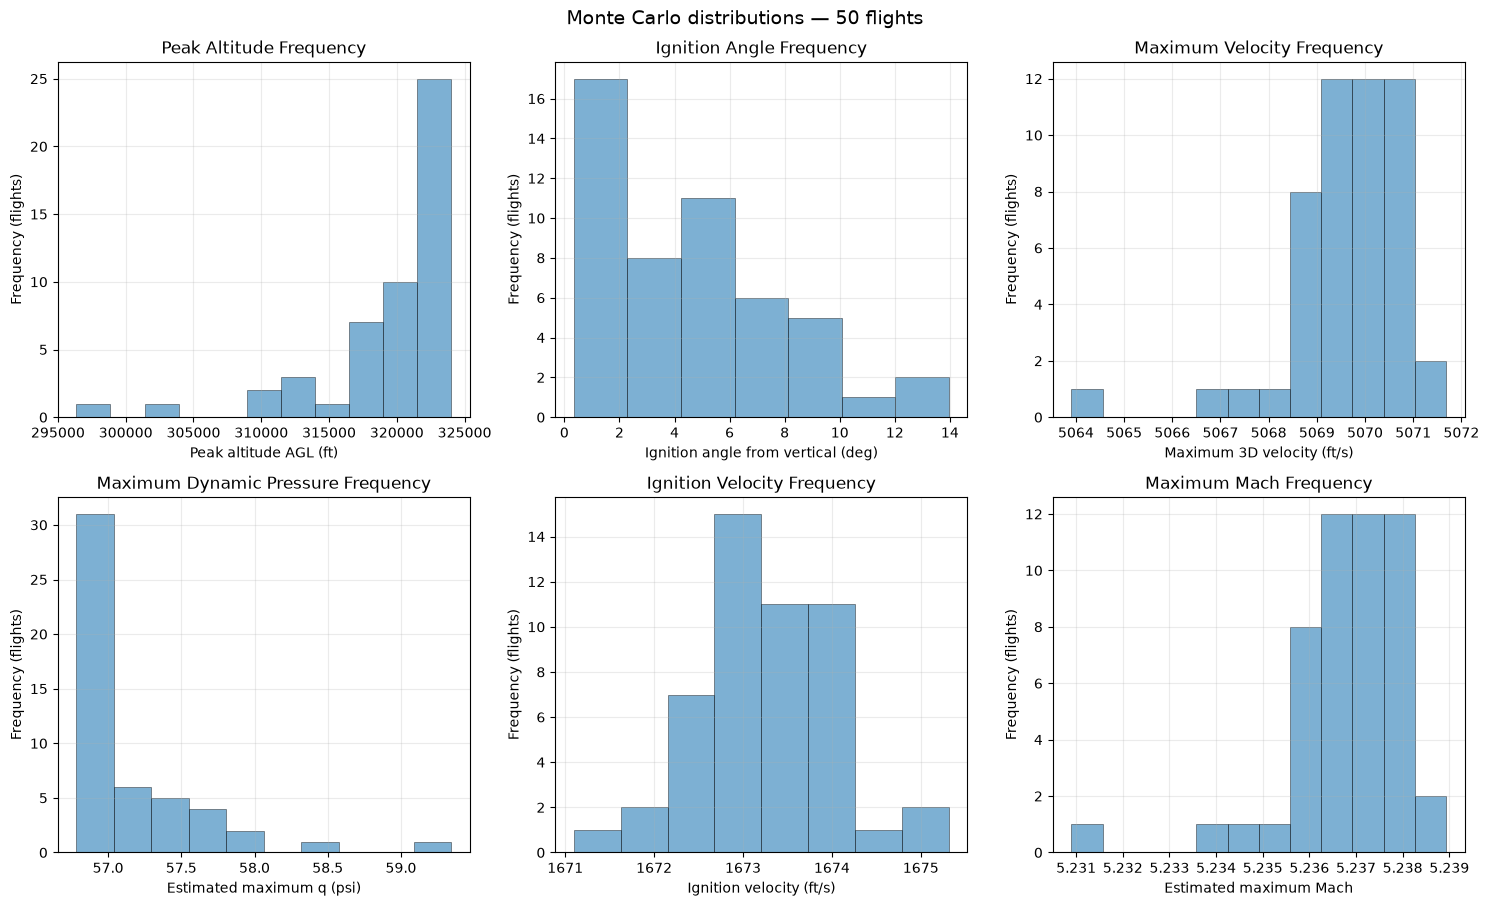

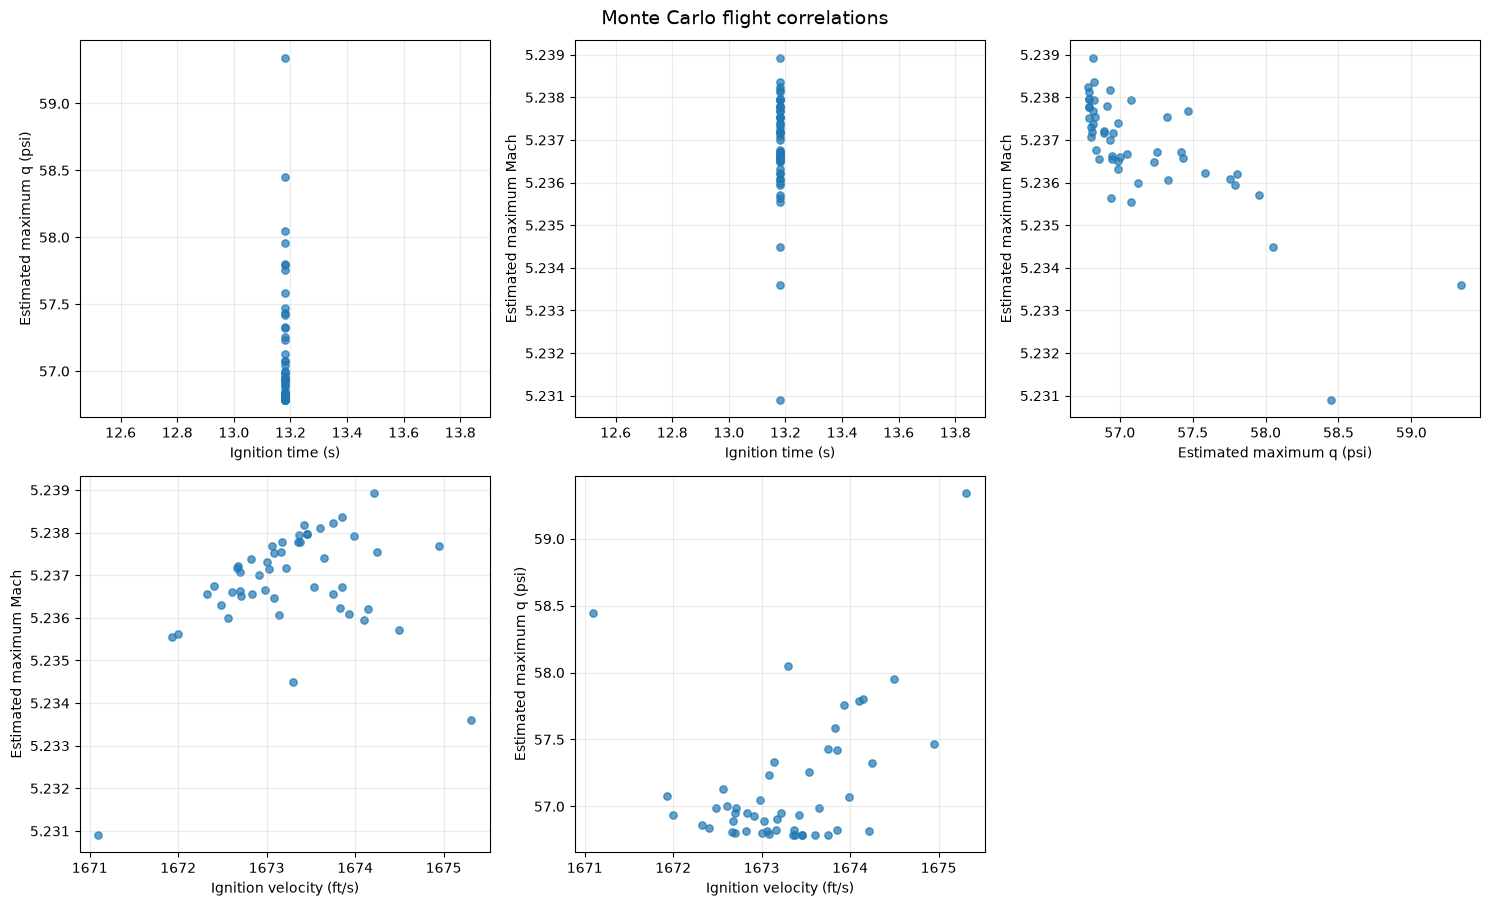

In [6]:
plot_definitions = [
    ("peak_altitude_ft_agl", "Peak altitude AGL (ft)", "Peak Altitude Frequency"),
    ("ignition_angle_deg_from_vertical", "Ignition angle from vertical (deg)", "Ignition Angle Frequency"),
    ("max_velocity_ft_s", "Maximum 3D velocity (ft/s)", "Maximum Velocity Frequency"),
    ("max_dynamic_pressure_psi_estimated", "Estimated maximum q (psi)", "Maximum Dynamic Pressure Frequency"),
    ("ignition_velocity_ft_s", "Ignition velocity (ft/s)", "Ignition Velocity Frequency"),
    ("max_mach_estimated", "Estimated maximum Mach", "Maximum Mach Frequency"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9.2))
axes = axes.ravel()
rocket_groups = list(flight_metrics.groupby("rocket_name", sort=False))

for axis, (metric, x_label, title) in zip(axes, plot_definitions):
    all_values = flight_metrics[metric].dropna().to_numpy()
    if all_values.size == 0:
        axis.text(0.5, 0.5, "No valid data", ha="center", va="center")
        continue
    shared_bins = np.histogram_bin_edges(all_values, bins=HISTOGRAM_BINS)
    for rocket_name, group in rocket_groups:
        axis.hist(
            group[metric].dropna(),
            bins=shared_bins,
            alpha=0.58,
            edgecolor="black",
            linewidth=0.5,
            label=rocket_name,
        )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Frequency (flights)")
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()

fig.suptitle(f"Monte Carlo distributions — {len(flight_metrics):,} flights", fontsize=14)
fig.tight_layout()
plt.show()

correlation_plots = [
    ("ignition_time_s", "max_dynamic_pressure_psi_estimated", "Ignition time (s)", "Estimated maximum q (psi)"),
    ("ignition_time_s", "max_mach_estimated", "Ignition time (s)", "Estimated maximum Mach"),
    ("max_dynamic_pressure_psi_estimated", "max_mach_estimated", "Estimated maximum q (psi)", "Estimated maximum Mach"),
    ("ignition_velocity_ft_s", "max_mach_estimated", "Ignition velocity (ft/s)", "Estimated maximum Mach"),
    ("ignition_velocity_ft_s", "max_dynamic_pressure_psi_estimated", "Ignition velocity (ft/s)", "Estimated maximum q (psi)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9.2))
axes = axes.ravel()
for axis, (x_metric, y_metric, x_label, y_label) in zip(axes, correlation_plots):
    for rocket_name, group in rocket_groups:
        axis.scatter(group[x_metric], group[y_metric], alpha=0.7, s=28, label=rocket_name)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()
for axis in axes[len(correlation_plots):]:
    axis.remove()
fig.suptitle("Monte Carlo flight correlations", fontsize=14)
fig.tight_layout()
plt.show()

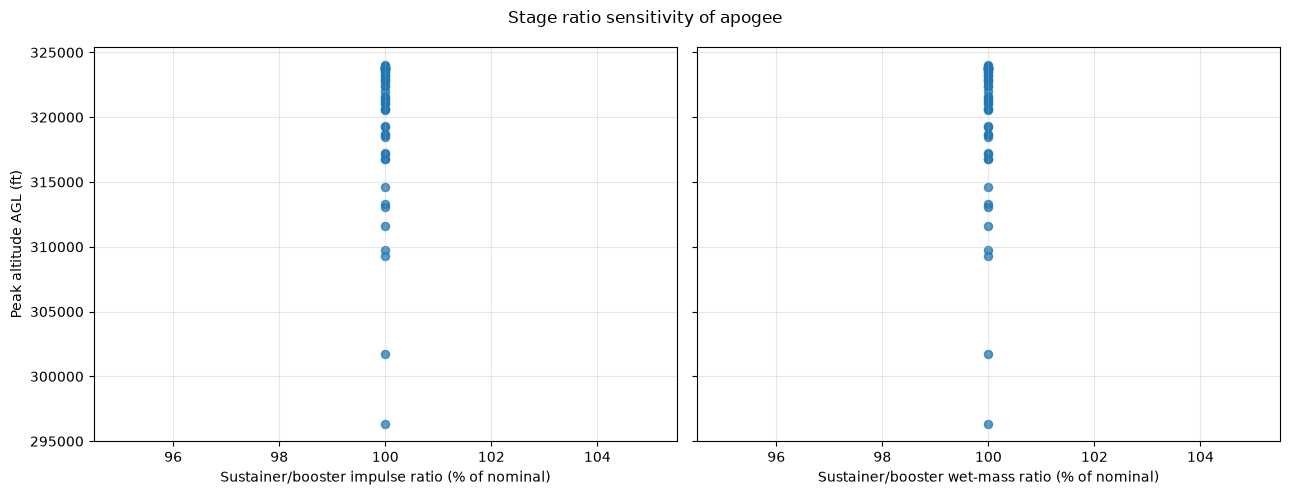

Impulse audit passed: booster + sustainer equals nominal total for every recorded flight.


,booster_impulse_n_s,sustainer_impulse_n_s,nominal_total_impulse_n_s,summed_realized_impulse_n_s,added_impulse_n_s
count,50.000,50.000,50.000,50.000,50.0
mean,24012.427,11822.105,35834.532,35834.532,0.0
std,0.000,0.000,0.000,0.000,0.0
min,24012.427,11822.105,35834.532,35834.532,0.0
25%,24012.427,11822.105,35834.532,35834.532,0.0
50%,24012.427,11822.105,35834.532,35834.532,0.0
75%,24012.427,11822.105,35834.532,35834.532,0.0
max,24012.427,11822.105,35834.532,35834.532,0.0


Observed low/high stage bounds across this Monte Carlo sweep:


,Low (SI),High (SI),SI unit,Low (imperial),High (imperial),Imperial unit
Quantity,,,,,,
Booster impulse,24012.427,24012.427,N s,5398.208,5398.208,lbf s
Sustainer impulse,11822.105,11822.105,N s,2657.715,2657.715,lbf s
Booster wet mass,16.465,16.465,kg,36.300,36.300,lb
Sustainer wet mass,13.018,13.018,kg,28.700,28.700,lb


In [7]:
ratio_parameter_labels = {
    "sustainer_booster_impulse_ratio_percent": "Sustainer/booster impulse ratio (% of nominal)",
    "sustainer_booster_mass_ratio_percent": "Sustainer/booster wet-mass ratio (% of nominal)",
}
ratio_records = []
for record_index, flight in enumerate(flights):
    parameters = flight.get("simulation_parameters", {})
    impulses = flight.get("stage_impulses", {})
    masses = flight.get("stage_masses", {})
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0:
        continue
    apogee_ft_agl = (np.nanmax(states[:, column["z"]]) - launch_elevation_m) * 3.28084
    ratio_records.append({
        "apogee_ft_agl": float(apogee_ft_agl),
        **{name: float(parameters.get(name, np.nan)) for name in ratio_parameter_labels},
        "booster_impulse_n_s": float(impulses.get("booster_impulse_n_s", np.nan)),
        "sustainer_impulse_n_s": float(impulses.get("sustainer_impulse_n_s", np.nan)),
        "nominal_total_impulse_n_s": float(impulses.get("nominal_total_impulse_n_s", np.nan)),
        "booster_wet_mass_kg": float(masses.get("booster_wet_mass_kg", np.nan)),
        "sustainer_wet_mass_kg": float(masses.get("sustainer_wet_mass_kg", np.nan)),
    })

ratio_sensitivity = pd.DataFrame.from_records(ratio_records)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axis, (parameter, label) in zip(axes, ratio_parameter_labels.items()):
    valid = ratio_sensitivity[[parameter, "apogee_ft_agl"]].dropna()
    if valid.empty:
        axis.text(0.5, 0.5, "No ratio sweep data", ha="center", va="center")
    else:
        axis.scatter(valid[parameter], valid["apogee_ft_agl"], s=34, alpha=0.75)
        if valid[parameter].nunique() > 1:
            coefficients = np.polyfit(valid[parameter], valid["apogee_ft_agl"], 1)
            x_fit = np.linspace(valid[parameter].min(), valid[parameter].max(), 100)
            axis.plot(x_fit, np.polyval(coefficients, x_fit), color="tab:red", linewidth=2, label="Linear trend")
            axis.legend()
    axis.set_xlabel(label)
    axis.grid(alpha=0.3)
axes[0].set_ylabel("Peak altitude AGL (ft)")
fig.suptitle("Stage ratio sensitivity of apogee")
fig.tight_layout()
plt.show()

impulse_columns = ["booster_impulse_n_s", "sustainer_impulse_n_s", "nominal_total_impulse_n_s"]
impulse_audit = ratio_sensitivity[impulse_columns].dropna().copy()
if impulse_audit.empty:
    print("Impulse audit unavailable: rerun montecarlorunner.py to store stage_impulses in the pickle.")
else:
    impulse_audit["summed_realized_impulse_n_s"] = (
        impulse_audit["booster_impulse_n_s"] + impulse_audit["sustainer_impulse_n_s"]
    )
    impulse_audit["added_impulse_n_s"] = (
        impulse_audit["summed_realized_impulse_n_s"] - impulse_audit["nominal_total_impulse_n_s"]
    )
    if not np.allclose(
        impulse_audit["summed_realized_impulse_n_s"],
        impulse_audit["nominal_total_impulse_n_s"],
        rtol=1e-12,
        atol=1e-6,
    ):
        maximum_error = impulse_audit["added_impulse_n_s"].abs().max()
        raise RuntimeError(f"Stage impulse redistribution added up to {maximum_error:.6g} N s")
    print("Impulse audit passed: booster + sustainer equals nominal total for every recorded flight.")

if not impulse_audit.empty:
    display(impulse_audit.describe().round(3))

bound_specs = [
    ("Booster impulse", "booster_impulse_n_s", "N s", 0.224808943, "lbf s"),
    ("Sustainer impulse", "sustainer_impulse_n_s", "N s", 0.224808943, "lbf s"),
    ("Booster wet mass", "booster_wet_mass_kg", "kg", 2.20462262, "lb"),
    ("Sustainer wet mass", "sustainer_wet_mass_kg", "kg", 2.20462262, "lb"),
]
bound_rows = []
for quantity, field, si_unit, conversion, imperial_unit in bound_specs:
    observed = ratio_sensitivity[field].dropna()
    if not observed.empty:
        bound_rows.append({
            "Quantity": quantity,
            "Low (SI)": observed.min(),
            "High (SI)": observed.max(),
            "SI unit": si_unit,
            "Low (imperial)": observed.min() * conversion,
            "High (imperial)": observed.max() * conversion,
            "Imperial unit": imperial_unit,
        })

stage_bounds = pd.DataFrame.from_records(bound_rows)
if stage_bounds.empty:
    print("Stage bounds unavailable: regenerate the Monte Carlo pickle with the current runner.")
else:
    print("Observed low/high stage bounds across this Monte Carlo sweep:")
    display(stage_bounds.set_index("Quantity").round(3))
    if len(stage_bounds) < len(bound_specs):
        print("Mass bounds unavailable in this older pickle; regenerate it with the current runner.")

## Export flight paths and landing points to Google Earth

The export converts RocketPy's local east/north coordinates to latitude and longitude around the launch site stored in the pickle. Flight-path altitude is written as absolute altitude above sea level. A landing placemark is added only when RocketPy reports impact or the final state reaches launch elevation.

`KML_MAX_PATH_POINTS` limits the number of coordinates per flight so large Monte Carlo sweeps remain responsive in Google Earth. Set it to `None` to export every state.

In [8]:
import simplekml

KML_OUTPUT_PATH = PROJECT_DIR / "monte_carlo_flights.kml"
KML_MAX_PATH_POINTS = 2_000
KML_LINE_WIDTH = 3

Saved Google Earth KML: C:\Users\E\Documents\GitHub\farfromheaven\sims\rocketpy\monte_carlo_flights.kml


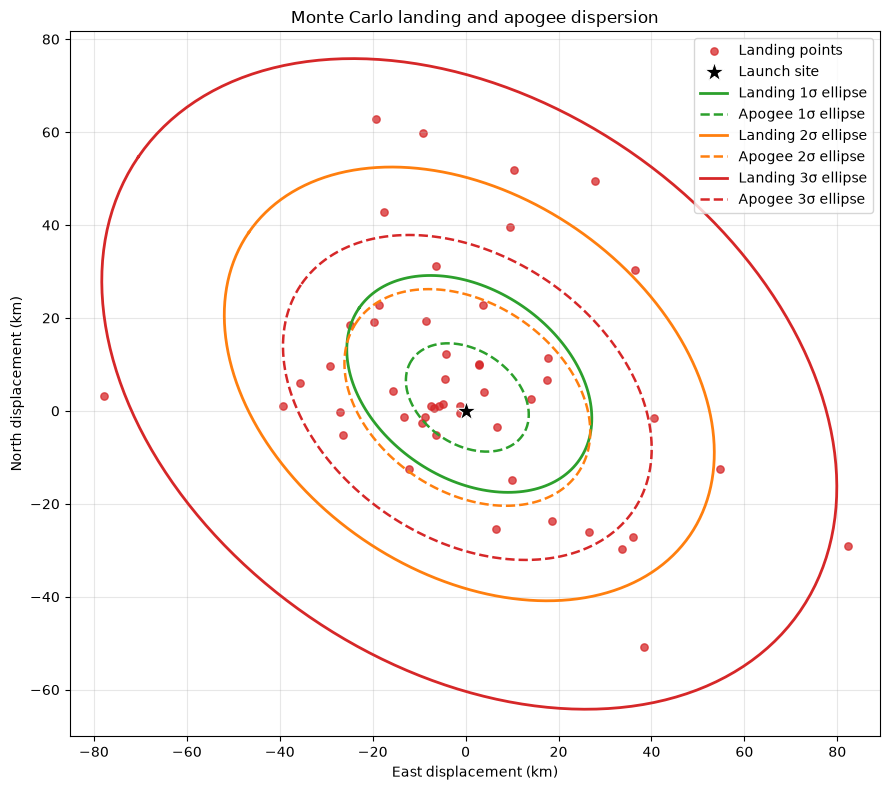

,simulation,rocket_name,states_in_pickle,path_points_exported,landing_exported
0,1,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7488,2000,True
1,2,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7451,2000,True
2,3,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7440,2000,True
3,4,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7376,2000,True
4,5,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7442,2000,True
5,6,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7523,2000,True
6,7,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7443,2000,True
7,8,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7482,2000,True
8,9,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7556,2000,True
9,10,AMA 4-3 Current Booster 2024 Sustainer - Full ...,7475,2000,True


In [9]:


EARTH_RADIUS_M = 6_378_137.0
environment_metadata = monte_carlo.get("environment", {})
origin_latitude = environment_metadata.get("latitude")
origin_longitude = environment_metadata.get("longitude")
origin_elevation_m = float(environment_metadata.get("elevation") or 0.0)
if origin_latitude is None or origin_longitude is None:
    raise ValueError("The pickle does not contain launch latitude and longitude")
origin_latitude = float(origin_latitude)
origin_longitude = float(origin_longitude)
longitude_scale = EARTH_RADIUS_M * np.cos(np.radians(origin_latitude))
if abs(longitude_scale) < 1e-9:
    raise ValueError("Cannot convert local coordinates at a geographic pole")

def local_xy_to_lon_lat(x_east_m, y_north_m):
    latitude = origin_latitude + np.degrees(float(y_north_m) / EARTH_RADIUS_M)
    longitude = origin_longitude + np.degrees(float(x_east_m) / longitude_scale)
    return longitude, latitude

def path_indices(state_count, maximum_points):
    if maximum_points is None or state_count <= maximum_points:
        return np.arange(state_count, dtype=int)
    return np.unique(np.linspace(0, state_count - 1, maximum_points, dtype=int))

def covariance_ellipse(points, standard_deviations=3.0, point_count=181):
    """Return the center, semi-axis lengths, and boundary of a 2-D covariance ellipse."""
    points = np.asarray(points, dtype=float)
    points = points[np.all(np.isfinite(points), axis=1)]
    if len(points) < 2:
        return None
    center = points.mean(axis=0)
    eigenvalues, eigenvectors = np.linalg.eigh(np.cov(points, rowvar=False))
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = np.maximum(eigenvalues[order], 0.0)
    eigenvectors = eigenvectors[:, order]
    semi_axes = standard_deviations * np.sqrt(eigenvalues)
    angles = np.linspace(0.0, 2.0 * np.pi, point_count)
    unit_circle = np.vstack((np.cos(angles), np.sin(angles)))
    boundary = center[:, None] + eigenvectors @ (semi_axes[:, None] * unit_circle)
    return center, semi_axes, boundary.T

kml = simplekml.Kml(name="Project Blaze Monte Carlo Flights")
paths_folder = kml.newfolder(name="Flight Paths")
landings_folder = kml.newfolder(name="Landing Points")
statistics_folder = kml.newfolder(name="Statistical Envelopes")

launch_point = kml.newpoint(
    name="Launch Site",
    coords=[(origin_longitude, origin_latitude, origin_elevation_m)],
)
launch_point.altitudemode = simplekml.AltitudeMode.absolute
launch_point.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/star.png"
launch_point.style.iconstyle.scale = 1.2

path_colors = [
    simplekml.Color.red,
    simplekml.Color.blue,
    simplekml.Color.green,
    simplekml.Color.orange,
    simplekml.Color.purple,
    simplekml.Color.cyan,
]
export_records = []
landing_points_xy = []
apogee_points_xyz = []
landing_color = simplekml.Color.red

for record_index, flight in enumerate(flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0:
        continue

    simulation_number = int(flight.get("simulation_index", record_index)) + 1
    rocket_name = flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}"
    feature_name = f"Run {simulation_number}"
    color = path_colors[record_index % len(path_colors)]
    indices = path_indices(len(states), KML_MAX_PATH_POINTS)
    coordinates = []
    for state in states[indices]:
        longitude, latitude = local_xy_to_lon_lat(state[column["x"]], state[column["y"]])
        coordinates.append((longitude, latitude, float(state[column["z"]])))
    apogee_index = int(np.nanargmax(states[:, column["z"]]))
    apogee_points_xyz.append([
        float(states[apogee_index, column["x"]]),
        float(states[apogee_index, column["y"]]),
        float(states[apogee_index, column["z"]]),
    ])

    path = paths_folder.newlinestring(name=feature_name, coords=coordinates)
    path.altitudemode = simplekml.AltitudeMode.absolute
    path.tessellate = 1
    path.style.linestyle.color = color
    path.style.linestyle.width = KML_LINE_WIDTH
    path.description = (
        f"States exported: {len(indices):,} of {len(states):,}\n"
        f"Launch inclination: {float(flight.get('launch_angle', np.nan)):.3f} deg"
    )

    events = flight.get("events", {})
    impact_time = events.get("impact_time")
    impact_x = events.get("x_impact")
    impact_y = events.get("y_impact")
    impact_detected = impact_time is not None and impact_x is not None and impact_y is not None
    if not impact_detected and states[-1, column["z"]] <= origin_elevation_m + 1.0:
        impact_detected = True
        impact_time = float(states[-1, column["time"]])
        impact_x = float(states[-1, column["x"]])
        impact_y = float(states[-1, column["y"]])

    if impact_detected:
        landing_points_xy.append([float(impact_x), float(impact_y)])
        landing_longitude, landing_latitude = local_xy_to_lon_lat(impact_x, impact_y)
        landing = landings_folder.newpoint(
            name=f"Landing — {feature_name}",
            coords=[(landing_longitude, landing_latitude, origin_elevation_m)],
        )
        landing.altitudemode = simplekml.AltitudeMode.absolute
        landing.style.iconstyle.color = landing_color
        landing.style.iconstyle.scale = 0.2
        landing.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
        landing.description = (
            f"Impact time: {float(impact_time):.2f} s\n"
            f"East offset: {float(impact_x):.1f} m\n"
            f"North offset: {float(impact_y):.1f} m"
        )

    export_records.append({
        "simulation": simulation_number,
        "rocket_name": rocket_name,
        "states_in_pickle": len(states),
        "path_points_exported": len(indices),
        "landing_exported": bool(impact_detected),
    })

sigma_levels = (1.0, 2.0, 3.0)
landing_ellipses = {
    sigma: covariance_ellipse(landing_points_xy, standard_deviations=sigma)
    for sigma in sigma_levels
}
apogee_points_xyz = np.asarray(apogee_points_xyz, dtype=float)
apogee_ellipses = {
    sigma: covariance_ellipse(apogee_points_xyz[:, :2], standard_deviations=sigma)
    if len(apogee_points_xyz) else None
    for sigma in sigma_levels
}

def add_kml_ellipse(name, ellipse, altitude_m, color, sigma):
    if ellipse is None:
        return
    center, semi_axes, boundary = ellipse
    coordinates = [(*local_xy_to_lon_lat(x, y), float(altitude_m)) for x, y in boundary]
    feature = statistics_folder.newlinestring(name=name, coords=coordinates)
    feature.altitudemode = simplekml.AltitudeMode.absolute
    feature.style.linestyle.color = color
    feature.style.linestyle.width = 5
    feature.description = (
        f"Center: {center[0]:.1f} m east, {center[1]:.1f} m north\n"
        f"{sigma:g}-sigma semi-axes: {semi_axes[0]:.1f} m, {semi_axes[1]:.1f} m"
    )

landing_sigma_colors = {1.0: simplekml.Color.orange, 2.0: simplekml.Color.yellow, 3.0: simplekml.Color.red}
apogee_sigma_colors = {1.0: simplekml.Color.cyan, 2.0: simplekml.Color.blue, 3.0: simplekml.Color.purple}
for sigma in sigma_levels:
    add_kml_ellipse(
        f"Landing {sigma:g}-sigma ellipse", landing_ellipses[sigma],
        origin_elevation_m, landing_sigma_colors[sigma], sigma,
    )
    add_kml_ellipse(
        f"Apogee {sigma:g}-sigma ellipse", apogee_ellipses[sigma],
        float(np.mean(apogee_points_xyz[:, 2])) if len(apogee_points_xyz) else origin_elevation_m,
        apogee_sigma_colors[sigma], sigma,
    )

KML_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
kml.save(str(KML_OUTPUT_PATH))
print(f"Saved Google Earth KML: {KML_OUTPUT_PATH}")

fig, axis = plt.subplots(figsize=(9, 8))
landing_points_xy = np.asarray(landing_points_xy, dtype=float)
if len(landing_points_xy):
    axis.scatter(landing_points_xy[:, 0] / 1000, landing_points_xy[:, 1] / 1000, color="tab:red", s=28, alpha=0.75, label="Landing points")
axis.scatter(0.0, 0.0, marker="*", color="black", edgecolor="white", s=220, linewidth=0.8, label="Launch site", zorder=5)
plot_sigma_colors = {1.0: "tab:green", 2.0: "tab:orange", 3.0: "tab:red"}
for sigma in sigma_levels:
    landing_ellipse = landing_ellipses[sigma]
    if landing_ellipse is not None:
        boundary = landing_ellipse[2]
        axis.plot(boundary[:, 0] / 1000, boundary[:, 1] / 1000, color=plot_sigma_colors[sigma], linewidth=2, label=f"Landing {sigma:g}σ ellipse")
    apogee_ellipse = apogee_ellipses[sigma]
    if apogee_ellipse is not None:
        boundary = apogee_ellipse[2]
        axis.plot(boundary[:, 0] / 1000, boundary[:, 1] / 1000, color=plot_sigma_colors[sigma], linestyle="--", linewidth=1.8, label=f"Apogee {sigma:g}σ ellipse")
axis.set_title("Monte Carlo landing and apogee dispersion")
axis.set_xlabel("East displacement (km)")
axis.set_ylabel("North displacement (km)")
axis.set_aspect("equal", adjustable="datalim")
axis.grid(alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

pd.DataFrame.from_records(export_records)